# Phase 2 — Exploratory Data Analysis
### IEEE-CIS Fraud Detection

This notebook is the evidence base for the modelling decisions taken in Phases 3–7.
It is organised around six questions, each of which changes something downstream:

1. **How imbalanced is the target, and is the imbalance stable over time?** → choice of metric and of validation scheme.
2. **What does `TransactionAmt` look like, and does it separate the classes?** → transforms in Phase 3.
3. **`TransactionDT` is a timedelta, not a clock — is there recoverable periodic structure anyway?** → the *assumed* calendar features.
4. **Is missingness informative (MNAR) rather than random?** → whether to impute or to encode.
5. **How redundant is the `V*` block?** → whether unsupervised compression (Phase 4) is worth doing.
6. **Which sub-populations differ in fraud rate?** → which interactions to build.

Every plot below is followed by an interpretation and a "so what" — what to include (features, splits,...) in the pipeline.

In [1]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score

import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()))
from src import config

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
FIG = config.FIGURES_DIR

df = pd.read_parquet(config.INTERIM_DIR / "train_joined.parquet")
y = df[config.TARGET].to_numpy()
df["day"] = (df[config.TIME_COL] // 86400).astype(int)
print(f"joined training frame: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print(f"time span: day {df['day'].min()} to day {df['day'].max()} "
      f"({df['day'].max() - df['day'].min() + 1} days)")

joined training frame: 590,540 rows x 436 columns
time span: day 1 to day 182 (182 days)


---
## 1. Class imbalance — and the fact that it moves

The headline number matters less than its instability. A fixed class prior can be handled with class weights;
a *drifting* one changes what precision means from month to month.

fraud: 20,663 / 590,540 = 3.4990%   (1 fraud per 29 transactions)
negative:positive ratio = 27.6 : 1


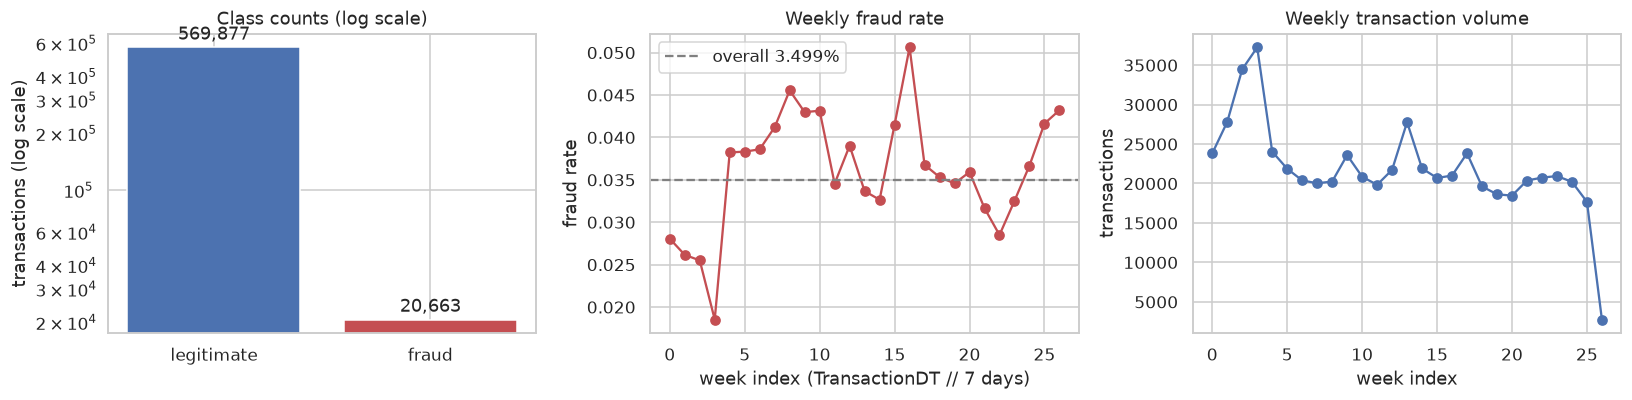


weekly fraud rate  min 1.8523%  max 5.0612%  (2.7x swing)
weekly volume      min 2,754  max 37,251

first 4 weeks: ['2.81%', '2.61%', '2.55%', '1.85%']
last  4 weeks: ['3.25%', '3.67%', '4.16%', '4.32%']


In [2]:
n = len(df); n_fraud = int(y.sum())
print(f"fraud: {n_fraud:,} / {n:,} = {y.mean():.4%}   (1 fraud per {n/n_fraud:.0f} transactions)")
print(f"negative:positive ratio = {(n-n_fraud)/n_fraud:.1f} : 1")

week = df["day"] // 7
wk = df.groupby(week)[config.TARGET].agg(n="size", rate="mean")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

axes[0].bar(["legitimate", "fraud"], [n - n_fraud, n_fraud], color=["#4C72B0", "#C44E52"])
axes[0].set_yscale("log"); axes[0].set_ylabel("transactions (log scale)")
axes[0].set_title("Class counts (log scale)")
for i, v in enumerate([n - n_fraud, n_fraud]):
    axes[0].text(i, v * 1.1, f"{v:,}", ha="center")

axes[1].plot(wk.index, wk["rate"], marker="o", color="#C44E52")
axes[1].axhline(y.mean(), ls="--", c="grey", label=f"overall {y.mean():.3%}")
axes[1].set_xlabel("week index (TransactionDT // 7 days)"); axes[1].set_ylabel("fraud rate")
axes[1].set_title("Weekly fraud rate"); axes[1].legend()

axes[2].plot(wk.index, wk["n"], marker="o", color="#4C72B0")
axes[2].set_xlabel("week index"); axes[2].set_ylabel("transactions")
axes[2].set_title("Weekly transaction volume")
plt.tight_layout(); plt.savefig(FIG / "02_class_imbalance.png", bbox_inches="tight"); plt.show()

print(f"\nweekly fraud rate  min {wk['rate'].min():.4%}  max {wk['rate'].max():.4%}  "
      f"({wk['rate'].max()/wk['rate'].min():.1f}x swing)")
print(f"weekly volume      min {wk['n'].min():,}  max {wk['n'].max():,}")
print("\nfirst 4 weeks:", [f"{v:.2%}" for v in wk['rate'].head(4)])
print("last  4 weeks:", [f"{v:.2%}" for v in wk['rate'].tail(4)])

**Interpretation.** The base rate is 3.50% — 27.6 legitimate transactions per fraud. That is severe but not
extreme; it seems enough positives (20,663) to train a neural network on. Applying the "10-to-1 rule of thumb" (>= 10 positive training examples per trainable parameter connected to minority class). Small nn for tabular data (30 input features → 32 nodes in hidden layer 1 → 16 nodes in hidden layer 2 → 1 output node) has roughly 1,500 trainable parameters which requires at least 15k total records and 1.5k for minority class (<= 20k).

The more consequential fact is the middle panel. Fraud rate is **not** a constant with noise on it: it runs
around 2.6% for the first month, dips to 1.85%, then climbs steadily to 4.3% by the final week — a 2.7×
swing between the quietest and busiest weeks. Volume (right panel) moves independently/ inversely, by 13.5×.

The first and last weeks are partial (the window opens mid-week and closes mid-week), which explains their
low volume, but not the sustained fraud-rate trend across the interior weeks.

**So what.**
- *Metric.* Because ROC-AUC is invariant to the class prior (non-fraud cases (TN) dominate heavily over TP -> FPR barely changes, making the ROC curve look identical regardless of class distribution shifts), it would hide this drift entirely. **PR-AUC is the primary metric** because precision is defined against the class prior, so a fold where fraud doubled shows up as a different number.
- *Validation.* Averaging metrics across time folds hides drift too. Phase 7 reports **per-fold** results.
- *Deployment.* A model trained on the first four months faces a period with roughly 1.6× the fraud rate it
  was fit on. Any absolute threshold calibrated on training data will be wrong at deployment because of distribution shift; Phase 7 evaluates the model by flagging the top 1% most suspicious cases.

---
## 2. `TransactionAmt` — heavy-tailed, and only weakly separating on its own

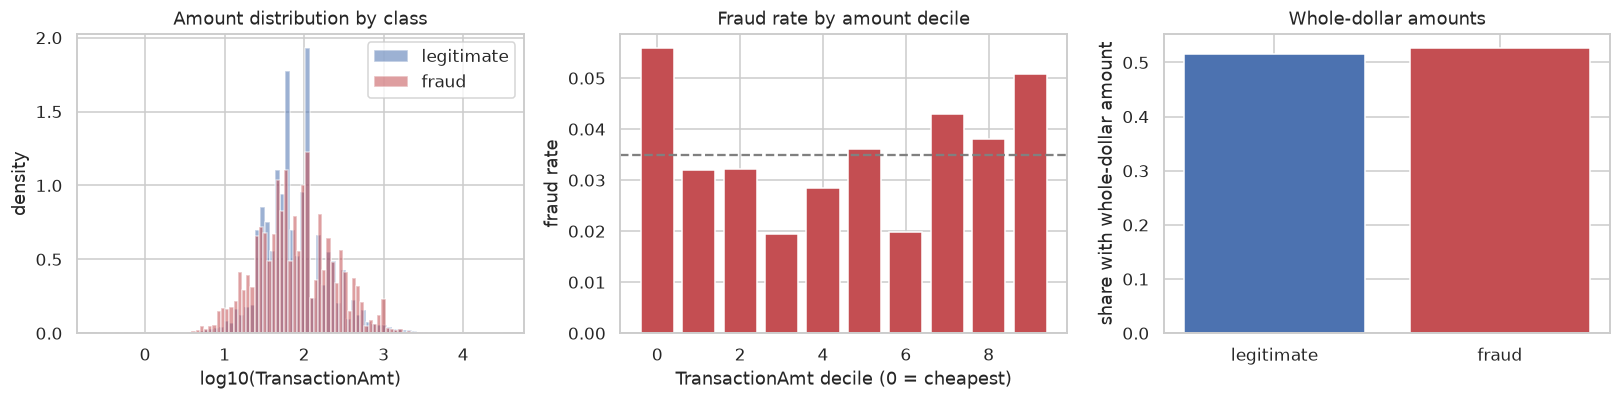

count    590540.00
mean        135.03
std         239.16
min           0.25
25%          43.32
50%          68.77
75%         125.00
max       31937.39

median amount   fraud 75.00   legit 68.50
mean   amount   fraud 149.24   legit 134.51
univariate ROC-AUC of raw amount: 0.4975


univariate ROC-AUC of decimal part: 0.4416


In [3]:
amt = df["TransactionAmt"]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

for lab, colour in [(0, "#4C72B0"), (1, "#C44E52")]:
    axes[0].hist(np.log10(amt[y == lab]), bins=80, density=True, alpha=0.55,
                 color=colour, label="fraud" if lab else "legitimate")
axes[0].set_xlabel("log10(TransactionAmt)"); axes[0].set_ylabel("density")
axes[0].set_title("Amount distribution by class"); axes[0].legend()

dec = pd.qcut(amt, 10, duplicates="drop")
g = df.groupby(dec, observed=True)[config.TARGET].mean()
axes[1].bar(range(len(g)), g.values, color="#C44E52")
axes[1].axhline(y.mean(), ls="--", c="grey")
axes[1].set_xlabel("TransactionAmt decile (0 = cheapest)"); axes[1].set_ylabel("fraud rate")
axes[1].set_title("Fraud rate by amount decile")

cents = amt - np.floor(amt)
is_round = (cents < 1e-6)
axes[2].bar(["legitimate", "fraud"], [is_round[y == 0].mean(), is_round[y == 1].mean()],
            color=["#4C72B0", "#C44E52"])
axes[2].set_ylabel("share with whole-dollar amount"); axes[2].set_title("Whole-dollar amounts")
plt.tight_layout(); plt.savefig(FIG / "02_amount.png", bbox_inches="tight"); plt.show()

print(amt.describe().round(2).to_string())
print(f"\nmedian amount   fraud {amt[y==1].median():.2f}   legit {amt[y==0].median():.2f}")
print(f"mean   amount   fraud {amt[y==1].mean():.2f}   legit {amt[y==0].mean():.2f}")
print(f"univariate ROC-AUC of raw amount: {roc_auc_score(y, amt):.4f}")
print(f"univariate ROC-AUC of decimal part: {roc_auc_score(y, cents):.4f}")

**Interpretation.** The amount distribution is right-skewed (median \$68.77, mean \$135.03, max
\$31,937) and roughly log-normal (the left panel is close to symmetric once logged, which is the standard
justification for a `log1p` transform).

Fraud and legitimate amount distributions **overlap almost completely**: the univariate ROC-AUC of raw amount is **0.4975**.
But the decile plot shows the relationship is **non-monotonic**: fraud rate is elevated at both the cheapest
decile (5.6% — card-testing, small charges used to check whether a stolen card is live) and the most
expensive decile (5.1% — cash-out), with a trough around \$50–120 (1.9%). A linear model in raw amount
cannot express a U-shape; a linear model in `log(amount)` cannot either. This is the first piece of
evidence that tree models have a structural advantage here over lienar baseline.

The share of whole-dollar transactions is slightly higher among fraud (52.7% vs 51.6%). The decimal component of transaction amounts carries non-random signal, achieving an inverse ROC-AUC of 0.4416 (equivalent to 0.5584 performance, or a +0.058 lift over a 0.50 random baseline). Fraudulent amounts have systematically smaller decimal parts, not just more zeros.
A plausible reading is that non-round amounts often reflect currency conversion or sales tax, so the decimal
digits are a weak proxy for transaction provenance; fraud skews toward clean, manually-entered figures.

**So what.** Phase 3 builds: `log1p(TransactionAmt)`; the decimal part as its own feature; and *amount
deciles* as a categorical, so the linear baseline gets a chance at the U-shape.

---
## 3. `TransactionDT` — no clock, but real periodic structure

`TransactionDT` is documented as a timedelta from an unknown reference. We cannot recover true local time.
What we *can* check is whether a 24-hour modular structure exists at all. If it does, the feature is useful
even though its zero point is unknown.

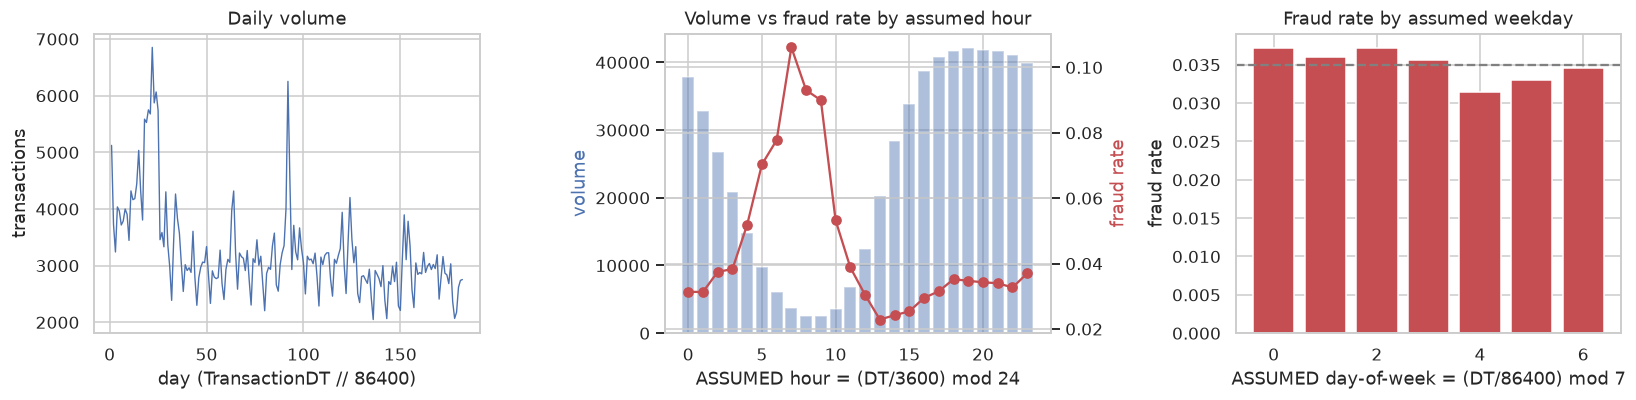

                   n    rate
TransactionDT               
0              37795  0.0314
1              32797  0.0313
2              26732  0.0375
3              20802  0.0383
4              14839  0.0519
5               9701  0.0703
6               6007  0.0777
7               3704  0.1061
8               2591  0.0930
9               2479  0.0900
10              3627  0.0532
11              6827  0.0388
12             12451  0.0304
13             20315  0.0229
14             28328  0.0242
15             33859  0.0254
16             38698  0.0295
17             40723  0.0315
18             41639  0.0352
19             42115  0.0347
20             41782  0.0343
21             41641  0.0340
22             41139  0.0327
23             39949  0.0370


In [4]:
assumed_hour = ((df[config.TIME_COL] // 3600) % 24).astype(int)
assumed_dow  = ((df[config.TIME_COL] // 86400) % 7).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

daily = df.groupby("day").size()
axes[0].plot(daily.index, daily.values, lw=0.9, color="#4C72B0")
axes[0].set_xlabel("day (TransactionDT // 86400)"); axes[0].set_ylabel("transactions")
axes[0].set_title("Daily volume")

h = df.groupby(assumed_hour)[config.TARGET].agg(n="size", rate="mean")
ax2 = axes[1].twinx()
axes[1].bar(h.index, h["n"], color="#4C72B0", alpha=0.45)
ax2.plot(h.index, h["rate"], color="#C44E52", marker="o")
axes[1].set_xlabel("ASSUMED hour = (DT/3600) mod 24"); axes[1].set_ylabel("volume", color="#4C72B0")
ax2.set_ylabel("fraud rate", color="#C44E52")
axes[1].set_title("Volume vs fraud rate by assumed hour")

d = df.groupby(assumed_dow)[config.TARGET].agg(n="size", rate="mean")
axes[2].bar(d.index, d["rate"], color="#C44E52")
axes[2].axhline(y.mean(), ls="--", c="grey")
axes[2].set_xlabel("ASSUMED day-of-week = (DT/86400) mod 7"); axes[2].set_ylabel("fraud rate")
axes[2].set_title("Fraud rate by assumed weekday")
plt.tight_layout(); plt.savefig(FIG / "02_time_structure.png", bbox_inches="tight"); plt.show()

print(h.assign(rate=lambda t: t["rate"].round(4)).to_string())

**Interpretation.** A clean 24-hour cycle exists. Volume falls from ~42,000 transactions at assumed hours
17–21 to ~2,500 at assumed hour 8 — a 16× diurnal swing, exactly the shape of a consumer payment stream over
a single dominant timezone. **The modular structure is real even though the offset is unknown.**

The fraud rate runs *counter* to volume: it peaks at **10.6% at assumed hour 7**, in the volume trough, and
bottoms at **2.3% at assumed hour 13**, at high volume — a 4.6× swing, larger than the ProductCD effect. The
natural reading: attackers transact while the cardholder is asleep and unlikely to notice
a notification, and while any human review team is thinnest. However, the low-volume hours have far fewer legitimate transactions diluting a roughly constant absolute number of
frauds, so part of this is a denominator effect, not purely an attacker choice.

The weekday panel is nearly flat (all bars within ~0.4pp of the mean), so the assumed day-of-week carries
little signal.

**So what.** Phase 3 creates `dt_hour_assumed` and `dt_dow_assumed`, both **explicitly labelled as assumed
alignments relative to an unknown origin** — in the column name, in the feature dictionary, and in the final
report. The hour feature is kept; the weekday feature is kept only as a control. Neither is ever
described as a real calendar feature. Crucially, `TransactionDT` itself is **not** used as a raw model input:
it increases monotonically, so a tree would split on it and learn "later = riskier," which is a fact about
this six-month window rather than about fraud, and would not transfer to the test period at all.

---
## 4. Missingness is informative — and the mechanism is MNAR

If missingness were random, imputation would be adequate and the missing-indicator would be noise.
We test that directly: for every column, build the binary "is null" indicator and score its univariate
ROC-AUC against `isFraud`. Under MCAR that AUC should sit at 0.5.

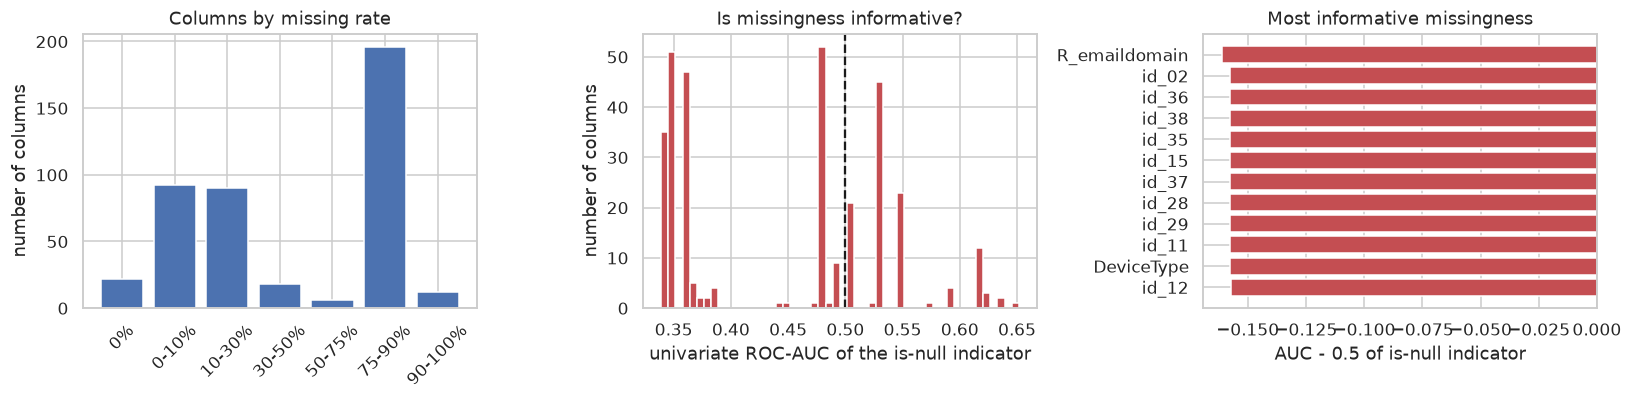

columns with a testable missing rate: 324
of those, |AUC - 0.5| > 0.05: 171  (53%)

columns fully populated: 22
columns >75% missing:    208

most informative:
          col  miss_rate    auc   lift
R_emaildomain     0.7675 0.3389 0.1611
        id_02     0.7615 0.3422 0.1578
        id_36     0.7613 0.3423 0.1577
        id_38     0.7613 0.3423 0.1577
        id_35     0.7613 0.3423 0.1577
        id_15     0.7613 0.3423 0.1577
        id_37     0.7613 0.3423 0.1577
        id_28     0.7613 0.3424 0.1576


In [5]:
miss = df.isna().mean().sort_values(ascending=False)
rows = []
for c in df.columns:
    if c in (config.TARGET, config.ID_COL, "day"):
        continue
    m = df[c].isna().to_numpy()
    r = m.mean()
    if r < 0.005 or r > 0.995:
        continue
    rows.append((c, r, roc_auc_score(y, m.astype(np.int8))))
isnull_auc = (pd.DataFrame(rows, columns=["col", "miss_rate", "auc"])
                .assign(lift=lambda d: (d["auc"] - 0.5).abs())
                .sort_values("lift", ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

buckets = pd.cut(miss, [-0.001, 0, .1, .3, .5, .75, .9, 1.0],
                 labels=["0%", "0-10%", "10-30%", "30-50%", "50-75%", "75-90%", "90-100%"])
bc = buckets.value_counts().sort_index()
axes[0].bar(bc.index.astype(str), bc.values, color="#4C72B0")
axes[0].set_ylabel("number of columns"); axes[0].set_title("Columns by missing rate")
axes[0].tick_params(axis="x", rotation=45)

axes[1].hist(isnull_auc["auc"], bins=50, color="#C44E52")
axes[1].axvline(0.5, ls="--", c="k")
axes[1].set_xlabel("univariate ROC-AUC of the is-null indicator")
axes[1].set_ylabel("number of columns"); axes[1].set_title("Is missingness informative?")

top = isnull_auc.head(12).iloc[::-1]
axes[2].barh(top["col"], top["auc"] - 0.5, color="#C44E52")
axes[2].axvline(0, c="k", lw=0.8)
axes[2].set_xlabel("AUC - 0.5 of is-null indicator"); axes[2].set_title("Most informative missingness")
plt.tight_layout(); plt.savefig(FIG / "02_missingness.png", bbox_inches="tight"); plt.show()

n_informative = int((isnull_auc["lift"] > 0.05).sum())
print(f"columns with a testable missing rate: {len(isnull_auc)}")
print(f"of those, |AUC - 0.5| > 0.05: {n_informative}  ({n_informative/len(isnull_auc):.0%})")
print(f"\ncolumns fully populated: {int((miss == 0).sum())}")
print(f"columns >75% missing:    {int((miss > 0.75).sum())}")
print("\nmost informative:")
print(isnull_auc.head(8).round(4).to_string(index=False))

**Interpretation.** Missingness in this dataset is largely **not** random. Of the 324 columns with a
missing rate between 0.5% and 99.5%, **171 (53%) have an is-null indicator whose univariate ROC-AUC differs
from 0.5 by more than 0.05.** Under MCAR you would expect essentially none.

The strongest indicators all point the *same* direction and all have a missing rate of ~76%: `R_emaildomain`,
`DeviceType`, and the whole `id_*` block sit at AUC ≈ 0.34. An AUC *below* 0.5 means **missing is associated
with the negative class**. That 76% figure is the mirror image of the 24.4% identity-join rate: these are
not 171 independent findings, they are largely one finding (whether an identity record exists at all)
replicated across every column that lives in the identity file.

The mechanism matters for interpretation. As argued in Phase 1 §4, the likely reason identity records
correlate with fraud is not that fingerprinted devices commit more fraud, but that the incumbent detection
system **collected extra identity signal on transactions it already suspected**. The missingness pattern is
partly a record of the prior policy's triage decisions.

**So what.**
- Never impute-and-forget. Phase 3 emits an explicit `*_isnull` indicator for the columns where missingness
  is informative, so the signal survives whatever the imputer does to the value.
- Because the identity-block indicators are near-duplicates of each other, emitting all 171 would add collinear noise. Phase 3 keeps has_identity_record as the single canonical version of that signal, plus 21 indicators for columns whose missingness carries information the join does not.
- For LightGBM, NaN is passed through natively (given it learns a default direction per split). For the linear and
  neural models, NaN must be filled (the indicator is what stops that fill from destroying information).

---
## 5. The `V*` block: 339 columns, far fewer independent dimensions

Vesta's `V1`–`V339` are undocumented engineered features. Two structural questions decide whether Phase 4's
unsupervised compression is worth doing: do they form natural groups, and how redundant are they inside a group?

339 V columns fall into 15 distinct missingness patterns


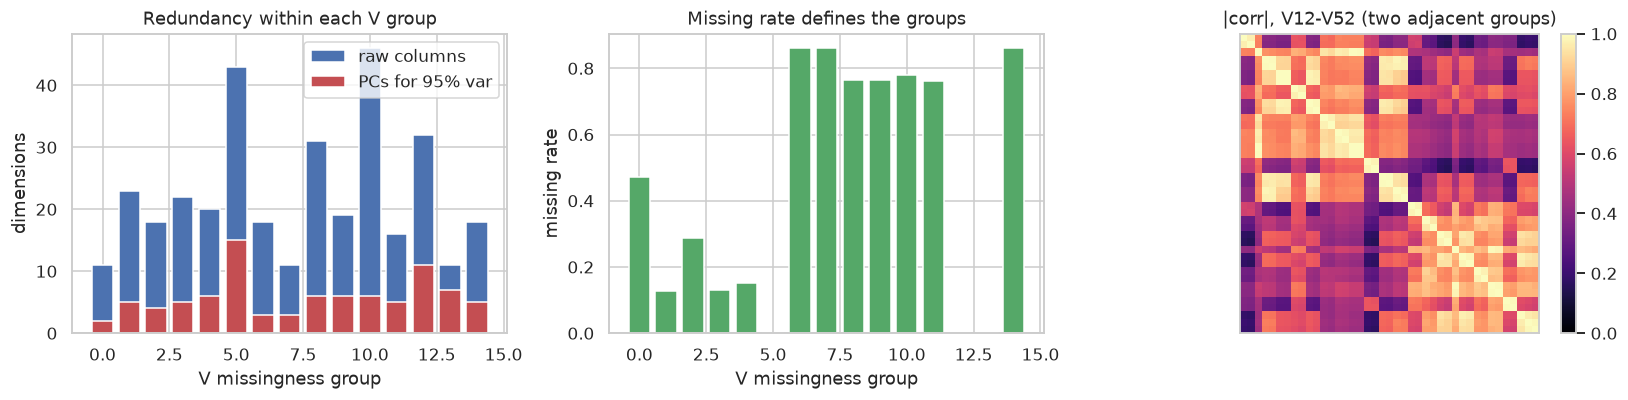

 group     range  n_cols  miss_rate  pc1_var  n_pc_95pct  mean_abs_corr  frac_pairs_r_gt_.9
     0    V1-V11      11     0.4729    0.942           2          0.850               0.612
     1   V12-V34      23     0.1288    0.749           5          0.695               0.242
     2   V35-V52      18     0.2861    0.796           4          0.737               0.179
     3   V53-V74      22     0.1306    0.728           5          0.670               0.198
     4   V75-V94      20     0.1510    0.719           6          0.660               0.140
     5  V95-V137      43     0.0005    0.364          15          0.277               0.087
     6 V138-V163      18     0.8612    0.769           3          0.651               0.315
     7 V143-V166      11     0.8612    0.685           3          0.550               0.264
     8 V167-V216      31     0.7636    0.480           6          0.419               0.154
     9 V169-V210      19     0.7632    0.680           6          0.575         

In [6]:
vcols = [c for c in config.V_COLS if c in df.columns]
vmiss = df[vcols].isna()

# Columns produced by the same upstream process share an identical missingness pattern,
# which is a cheap and exact way to recover the block structure.
groups = {}
for c in vcols:
    groups.setdefault(hash(vmiss[c].to_numpy().tobytes()), []).append(c)
groups = sorted(groups.values(), key=lambda g: int(g[0][1:]))
print(f"{len(vcols)} V columns fall into {len(groups)} distinct missingness patterns")

rec = []
for i, g in enumerate(groups):
    X = np.nan_to_num(df[g].to_numpy(dtype=np.float32), nan=-1.0)
    Xs = (X - X.mean(0)) / (X.std(0) + 1e-9)
    p = PCA(n_components=min(len(g), 40), random_state=config.RANDOM_SEED).fit(Xs)
    cum = np.cumsum(p.explained_variance_ratio_)
    Cm = np.corrcoef(Xs.T); np.fill_diagonal(Cm, 0.0)
    nums = [int(c[1:]) for c in g]
    rec.append({"group": i, "range": f"V{min(nums)}-V{max(nums)}", "n_cols": len(g),
                "miss_rate": round(float(vmiss[g[0]].mean()), 4),
                "pc1_var": round(float(p.explained_variance_ratio_[0]), 3),
                "n_pc_95pct": int(np.searchsorted(cum, 0.95) + 1),
                "mean_abs_corr": round(float(np.nanmean(np.abs(Cm))), 3),
                "frac_pairs_r_gt_.9": round(float(np.nanmean(np.abs(Cm) > 0.9)), 3)})
vsum = pd.DataFrame(rec)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].bar(vsum["group"], vsum["n_cols"], color="#4C72B0", label="raw columns")
axes[0].bar(vsum["group"], vsum["n_pc_95pct"], color="#C44E52", label="PCs for 95% var")
axes[0].set_xlabel("V missingness group"); axes[0].set_ylabel("dimensions")
axes[0].set_title("Redundancy within each V group"); axes[0].legend()

axes[1].bar(vsum["group"], vsum["miss_rate"], color="#55A868")
axes[1].set_xlabel("V missingness group"); axes[1].set_ylabel("missing rate")
axes[1].set_title("Missing rate defines the groups")

sub = [c for c in vcols if 12 <= int(c[1:]) <= 52]
Cm = np.corrcoef(np.nan_to_num(df[sub].to_numpy(dtype=np.float32), nan=-1.0).T)
im = axes[2].imshow(np.abs(Cm), cmap="magma", vmin=0, vmax=1)
axes[2].set_title("|corr|, V12-V52 (two adjacent groups)")
axes[2].set_xticks([]); axes[2].set_yticks([])
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.tight_layout(); plt.savefig(FIG / "02_v_block_structure.png", bbox_inches="tight"); plt.show()

print(vsum.to_string(index=False))
print(f"\nTOTAL: {len(vcols)} raw V columns -> {int(vsum['n_pc_95pct'].sum())} PCs retain 95% of "
      f"within-group variance ({1 - vsum['n_pc_95pct'].sum()/len(vcols):.0%} reduction)")

**Interpretation.** The `V*` block is not 339 independent measurements. Grouping columns by their *exact*
missingness pattern — columns computed by the same upstream process go missing together — recovers **15
clean groups** whose ranges are almost perfectly contiguous (`V1–V11`, `V12–V34`, `V35–V52`, … `V322–V339`).
Missing rates cluster into three regimes: near-zero (`V95–V137`, `V279–V321`), moderate 13–47%, and ~76–86%
(the identity-linked groups).

Within a group the redundancy is severe. In `V1–V11` the first principal component alone explains **94.2%**
of variance and 61% of all column pairs correlate above |r| = 0.9. Across all 15 groups, **89 principal
components retain 95% of within-group variance — a 74% dimensionality reduction.** The heatmap shows why:
`V12–V52` is visibly two dense blocks of near-duplicate columns with weak cross-block coupling.

**So what.** This is the empirical justification for Phase 4. Compressing each group with PCA is not
decoration — it removes ~250 collinear columns, which matters most for the two model families that suffer
from collinearity: the linear baseline (unstable coefficients, inflated variance) and the neural network
(wasted first-layer capacity, slower convergence). Gradient boosting is largely immune (If a dataset contains cluster-like structures, a sufficiently deep tree learns these non-linear boundaries automatically using raw features), which gives us a clean comparison: if the cluster/PCA features help the linear and neural models but not the GBM, the engineered features successfully captured true geometric structures in the data.

---
## 6. Sub-populations: where the fraud rate actually differs

Ranked by effect size, since that is what determines which interactions are worth building.

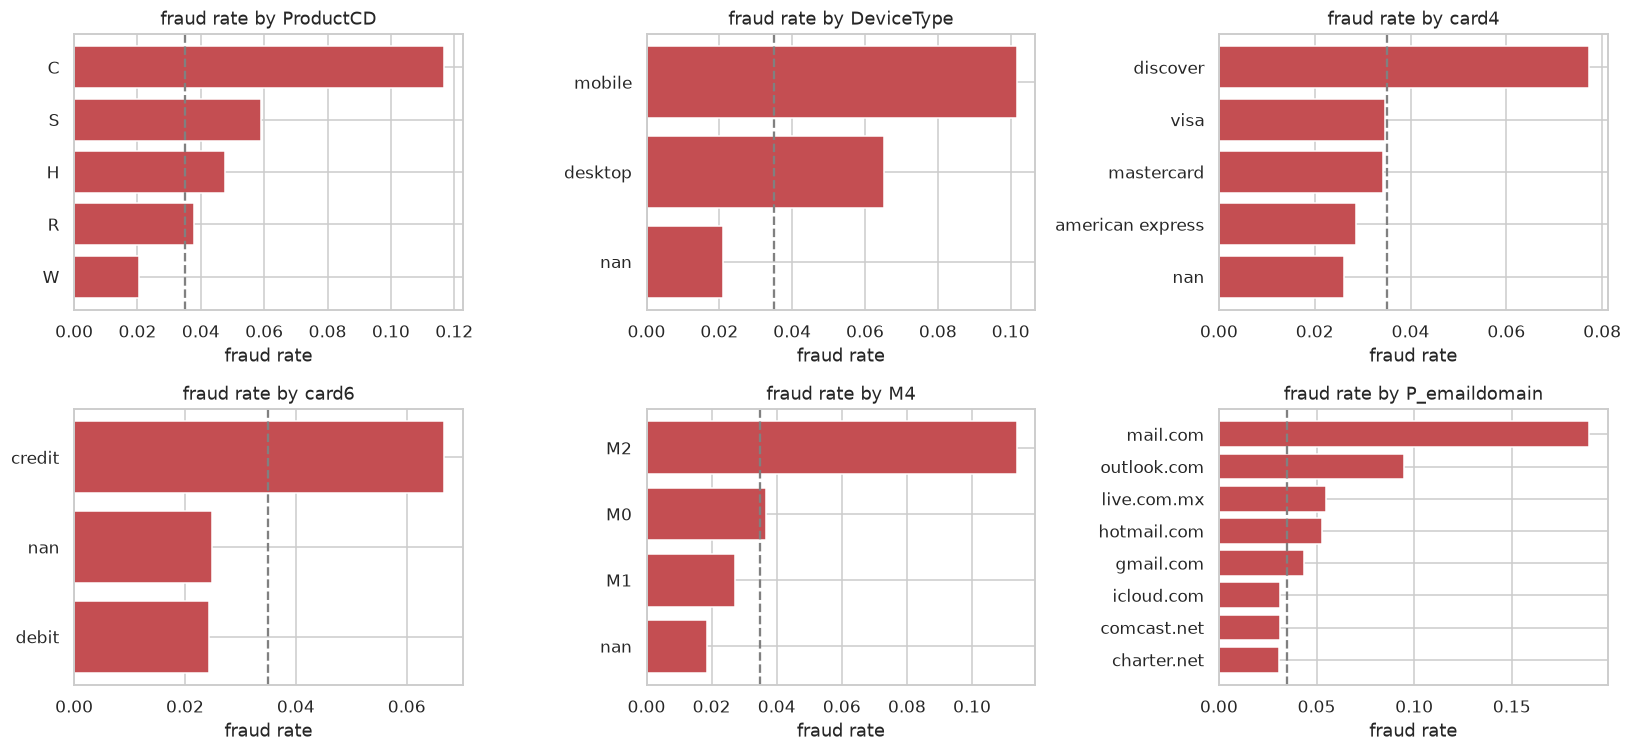


--- ProductCD ---
                n  fraud_rate
ProductCD                    
C           68519      0.1169
S           11628      0.0590
H           33024      0.0477
R           37699      0.0378
W          439670      0.0204

--- DeviceType ---
                 n  fraud_rate
DeviceType                    
mobile       55645      0.1017
desktop      85165      0.0652
NaN         449730      0.0210

--- id_31 ---
                               n  fraud_rate
id_31                                       
firefox                      673      0.2184
chrome generic              4778      0.1681
chrome 64.0 for android     3473      0.1589
chrome 65.0 for android     3336      0.1472
chrome 61.0 for android      538      0.1338
chrome 66.0 for android     2349      0.1298
chrome 63.0 for android     5806      0.1125
chrome generic for android  1158      0.1097

--- R_emaildomain ---
                   n  fraud_rate
R_emaildomain                   
outlook.com     2507      0.1651
icloud.co

In [7]:
def rate_table(col, min_n=500, top=8):
    g = (df.groupby(col, observed=True, dropna=False)[config.TARGET]
           .agg(n="size", fraud_rate="mean"))
    return g[g["n"] >= min_n].sort_values("fraud_rate", ascending=False).head(top)

panels = ["ProductCD", "DeviceType", "card4", "card6", "M4", "P_emaildomain"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), panels):
    t = rate_table(col)
    ax.barh([str(i) for i in t.index][::-1], t["fraud_rate"].values[::-1], color="#C44E52")
    ax.axvline(y.mean(), ls="--", c="grey")
    ax.set_title(f"fraud rate by {col}"); ax.set_xlabel("fraud rate")
plt.tight_layout(); plt.savefig(FIG / "02_subpopulations.png", bbox_inches="tight"); plt.show()

for col in ["ProductCD", "DeviceType", "id_31", "R_emaildomain"]:
    print(f"\n--- {col} ---")
    print(rate_table(col).assign(fraud_rate=lambda t: t["fraud_rate"].round(4)).to_string())

**Interpretation.** The largest single-column effects, all against a 3.50% base rate:

| Split | High-risk level | Low-risk level | Ratio |
|---|---|---|---|
| `ProductCD` | C — 11.69% (n=68,519) | W — 2.04% (n=439,670) | **5.7×** |
| Assumed hour | hour 7 — 10.61% | hour 13 — 2.29% | 4.6× |
| `DeviceType` | mobile — 10.17% | missing — 2.10% | 4.8× |
| `M4` | M2 — 11.37% (n=59,865) | missing — 1.86% | 6.1× |
| `R_emaildomain` | outlook.com — 16.51% | aol.com — 3.49% | 4.7× |
| `card4` | discover — 7.73% (n=6,651) | amex — 2.87% | 2.7× |
| `id_31` (browser) | firefox generic — 21.84% (n=673) | — | 6.2× vs base |

Two things stand out. First, `ProductCD = W` is 74% of all volume at a 2.04% fraud rate, while `C` is 12% of
volume at 11.69% — so **`ProductCD` is close to a partition of the problem into different regimes** rather
than one more feature. Second, the recipient email domain (`R_emaildomain`, 16.5% for outlook.com) separates
much more sharply than the purchaser domain (`P_emaildomain`, 4.4% for gmail.com), which fits a
send-to-a-disposable-address pattern.


**So what.** Phase 3 builds interactions on the axes that separate most: `ProductCD × card4/card6`,
`ProductCD × assumed hour`, `DeviceType × P_emaildomain`, and `card1 × addr1` as a finer entity proxy.
Rare-level protection matters — `id_31` has hundreds of levels with tiny counts, so frequency encoding and a
minimum-count floor are used rather than raw one-hot.

---
## 7. Fraud clusters within proxy entities — the case against a random split

This is the EDA result with the largest consequence for the whole project.

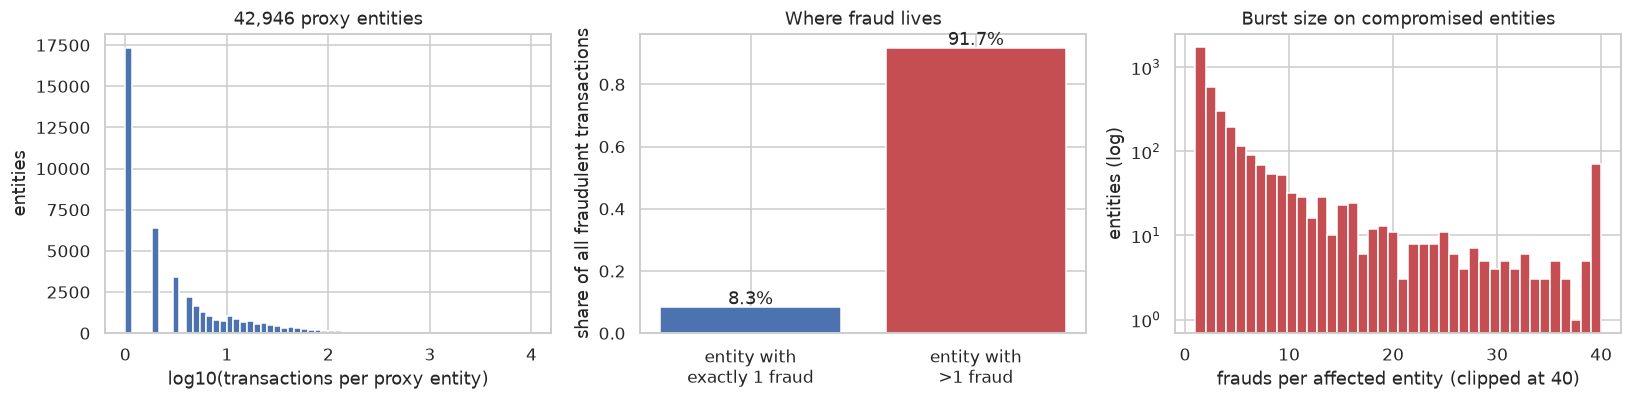

proxy entities:                       42,946
entities seen exactly once:           40.3%
median / mean txns per entity:        2 / 13.8
largest entity:                       9,900 transactions
entities ever carrying fraud:         8.25%
share of fraud in >1-fraud entities:  91.7%


In [8]:
# Use the project's own key builder: it maps a missing component to an "NA"
# level. A naive `a.astype(str) + "_" + b.astype(str)` propagates NaN across
# the whole concatenation in pandas 3, which would silently collapse the
# 75,885 rows that have at least one missing component into one pseudo-entity.
from src.features.build_features import _concat_key
uid = _concat_key(df, ["card1", "card2", "card3", "card5", "addr1"])
ent = pd.DataFrame({"uid": uid, "y": y}).groupby("uid")["y"].agg(n="size", n_fraud="sum")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].hist(np.log10(ent["n"]), bins=60, color="#4C72B0")
axes[0].set_xlabel("log10(transactions per proxy entity)"); axes[0].set_ylabel("entities")
axes[0].set_title(f"{len(ent):,} proxy entities")

share = [ent.loc[ent["n_fraud"] == k, "n_fraud"].sum() / ent["n_fraud"].sum()
         for k in [1]] + [ent.loc[ent["n_fraud"] > 1, "n_fraud"].sum() / ent["n_fraud"].sum()]
axes[1].bar(["entity with\nexactly 1 fraud", "entity with\n>1 fraud"], share, color=["#4C72B0", "#C44E52"])
axes[1].set_ylabel("share of all fraudulent transactions")
axes[1].set_title("Where fraud lives")
for i, v in enumerate(share):
    axes[1].text(i, v + 0.01, f"{v:.1%}", ha="center")

fr = ent[ent["n_fraud"] > 0]
axes[2].hist(np.clip(fr["n_fraud"], 0, 40), bins=40, color="#C44E52")
axes[2].set_yscale("log")
axes[2].set_xlabel("frauds per affected entity (clipped at 40)"); axes[2].set_ylabel("entities (log)")
axes[2].set_title("Burst size on compromised entities")
plt.tight_layout(); plt.savefig(FIG / "02_entity_clustering.png", bbox_inches="tight"); plt.show()

print(f"proxy entities:                       {len(ent):,}")
print(f"entities seen exactly once:           {(ent['n']==1).mean():.1%}")
print(f"median / mean txns per entity:        {ent['n'].median():.0f} / {ent['n'].mean():.1f}")
print(f"largest entity:                       {ent['n'].max():,} transactions")
print(f"entities ever carrying fraud:         {(ent['n_fraud']>0).mean():.2%}")
print(f"share of fraud in >1-fraud entities:  {ent.loc[ent['n_fraud']>1,'n_fraud'].sum()/ent['n_fraud'].sum():.1%}")

**Interpretation.** Fraud is bursty and entity-bound. Only **8.3%** of the 42,946 proxy entities ever carry a
fraud label, but **91.7% of all fraudulent transactions sit in entities that carry more than one fraud.**
A compromised credential is not defrauded once; it is drained.

That single fact invalidates random cross-validation for this dataset. Under a shuffled split, transaction
#4 of a nine-fraud burst lands in train and transaction #7 lands in validation. The model can then score
well on validation by recognising the *entity* — `card1`/`addr1` are right there in the feature set — without
having learned anything transferable.

The right panel shows the burst-size distribution is itself heavy-tailed: most affected entities show one or
two frauds, a long tail shows dozens.

**So what.** Phase 7 uses a **strictly chronological** split and expanding-window folds, and
`src/data/split.assert_no_time_overlap` enforces it as a hard assertion rather than a convention. Phase 8
quantifies exactly how much a random split would have inflated the numbers. Note also that a chronological
split does not fully eliminate entity overlap — an entity active in month 1 may still be active in month 5 —
but it makes the overlap *realistic*: at deployment you genuinely do know a card's history up to now. What
you must never know is its future, and time-ordering guarantees that.

## 8. What EDA pushed

| Finding | Consequence |
|---|---|
| Fraud rate drifts 1.85% → 5.06% across weeks | PR-AUC as primary metric; **per-fold** reporting; review-budget operating point instead of a fixed probability threshold. |
| Fraud skews toward smaller/round decimals (inverse AUC 0.4416; +0.058 lift); overall Amount → fraud is **U-shaped** | `log1p` transform, amount-decile bins (for linear non-monotonicity), and explicit decimal/cents feature engineering (`amount_decimal`). |
| Clean 24-h periodicity, fraud peaks 4.6× in the volume trough | `dt_hour_assumed` is worth building — labelled as an assumed alignment. Raw `TransactionDT` excluded as a model input (monotone; would encode "later = riskier"). |
| 53% of testable columns have informative missingness (MNAR). Missingness spans 3 distinct structural relationships with `has_identity`: independent (e.g. `card2`, `P_email`), join-driven (e.g. `D8/D9`), and inversely tied (e.g. `M1`, `addr1`) | Explicit `*_isnull` indicators alongside canonical `has_identity_record`; avoids blanket MNAR assumptions across distinct missingness mechanisms; NaN passed natively to LightGBM (LightGBM handles NaNs natively by treating them as distinct/learnable state rather than requiring imputation). |
| 339 `V*` columns → 89 PCs for 95% within-group variance | Phase 4 PCA/clustering is justified as compression, targeted at the linear and neural models specifically. |
| `ProductCD` splits the problem 5.7× (C vs W), on 74%/12% of volume | `ProductCD` interactions prioritised; considered as a regime variable, not just a category. |
| 91.7% of fraud sits in repeat-fraud entities | Chronological split enforced by assertion; strictly-backward-looking entity aggregations only (Phase 3); quantified in the Phase 8 leakage audit. |